In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
print("Setup selesai")

Setup selesai


In [3]:
df = pd.read_csv('retail_sales.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536532,10009,PARTY BUNTING,1,11/24/2019 18:00,2.36,NaN,Portugal
1,537816,10016,VINTAGE SNAKES AND LADDERS,2,11/05/2019 01:00,11.33,16962.0,France
2,537592,10003,GLASS JAR CANDLE,1742,01/15/2020 07:00,1.42,15088.0,United Kingdom
3,537187,10002,RED WOOLLY HOTTIE MUG,2,01/21/2020 23:00,0.65,14753.0,United Kingdom
4,537176,10016,VINTAGE SNAKES AND LADDERS,3,02/01/2020 17:00,3.16,18073.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    5000 non-null   int64  
 1   StockCode    5000 non-null   int64  
 2   Description  4990 non-null   str    
 3   Quantity     5000 non-null   int64  
 4   InvoiceDate  5000 non-null   str    
 5   UnitPrice    5000 non-null   float64
 6   CustomerID   4000 non-null   float64
 7   Country      5000 non-null   str    
dtypes: float64(2), int64(3), str(3)
memory usage: 561.3 KB


In [5]:
df.describe()

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID
count,5000.000000,5000.000000,5000.000000,5000.000000,4000.000000
mean,537299.460200,10009.452000,13.505800,14.016208,15328.337750
std,542.682959,5.810477,166.531689,256.454842,1731.450489
min,536365.000000,10000.000000,1.000000,0.250000,12346.000000
25%,536827.750000,10004.000000,2.000000,1.250000,13827.000000
50%,537291.000000,10009.000000,4.000000,2.410000,15364.000000
75%,537774.000000,10014.000000,8.000000,4.810000,16812.000000
max,538239.000000,10019.000000,7721.000000,7963.050000,18286.000000


In [7]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df[missing_df['Missing'] > 0]

,Missing,Percent
Description,10,0.2
CustomerID,1000,20.0


In [8]:
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['Description'] = df_clean['Description'].fillna('Unknown')
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

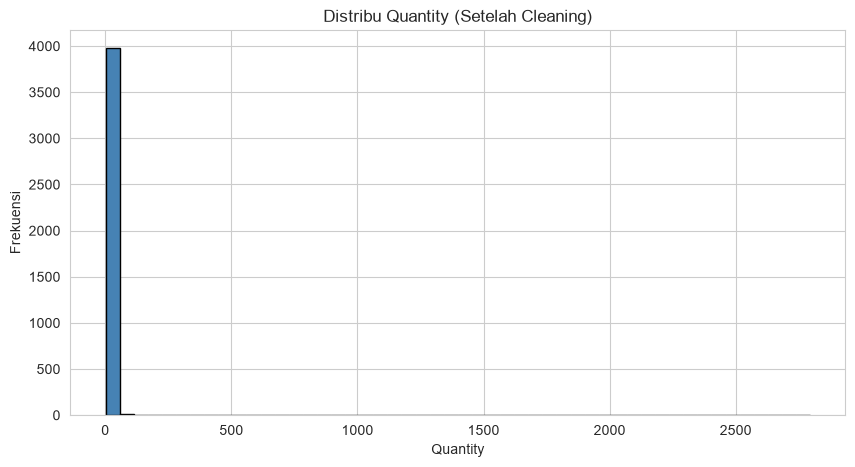

In [9]:
plt.figure(figsize=(10, 5))
df_clean['Quantity'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribu Quantity (Setelah Cleaning)')
plt.xlabel('Quantity')
plt.ylabel('Frekuensi')
plt.show()

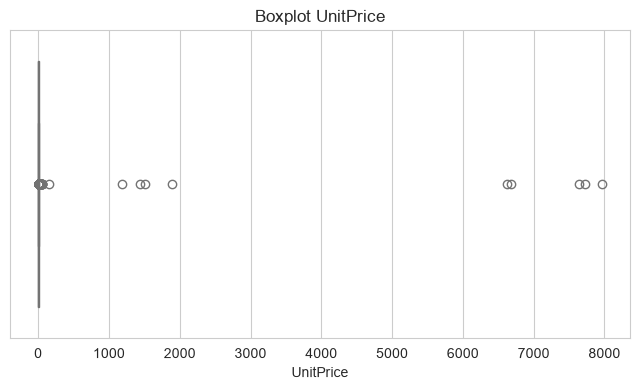

In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['UnitPrice'], color='lightgreen')
plt.title('Boxplot UnitPrice')
plt.show()

Shape sebelum filtering: (4000, 8)
Shape sesudah filtering: (3664, 8)


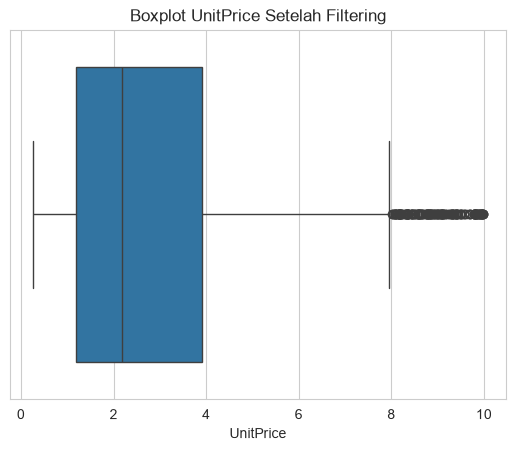

In [11]:
Q1 = df_clean['UnitPrice'].quantile(0.25)
Q3 = df_clean['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1
low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR

df_filtered = df_clean[(df_clean['UnitPrice'] >= low) & (df_clean['UnitPrice'] <= high)]
print("Shape sebelum filtering:", df_clean.shape)
print("Shape sesudah filtering:", df_filtered.shape)

sns.boxplot(x=df_filtered['UnitPrice'])
plt.title('Boxplot UnitPrice Setelah Filtering')
plt.show()

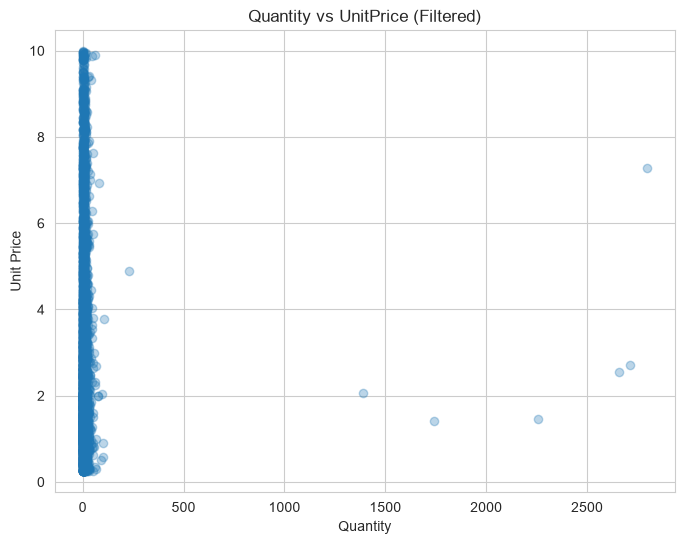

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(df_filtered['Quantity'], df_filtered['UnitPrice'], alpha=0.3)
plt.xlabel('Quantity')
plt.ylabel('Unit Price')
plt.title('Quantity vs UnitPrice (Filtered)')
plt.show()

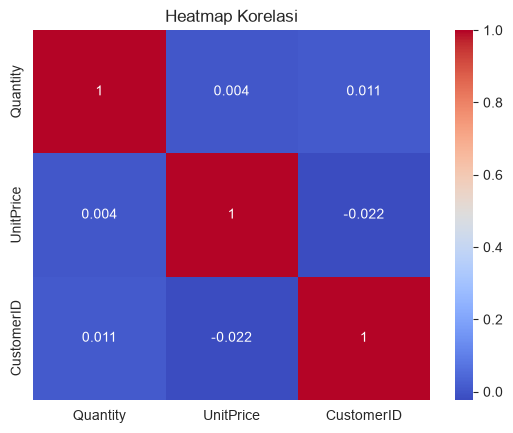

In [13]:
num_cols = ['Quantity', 'UnitPrice', 'CustomerID']
corr = df_filtered[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

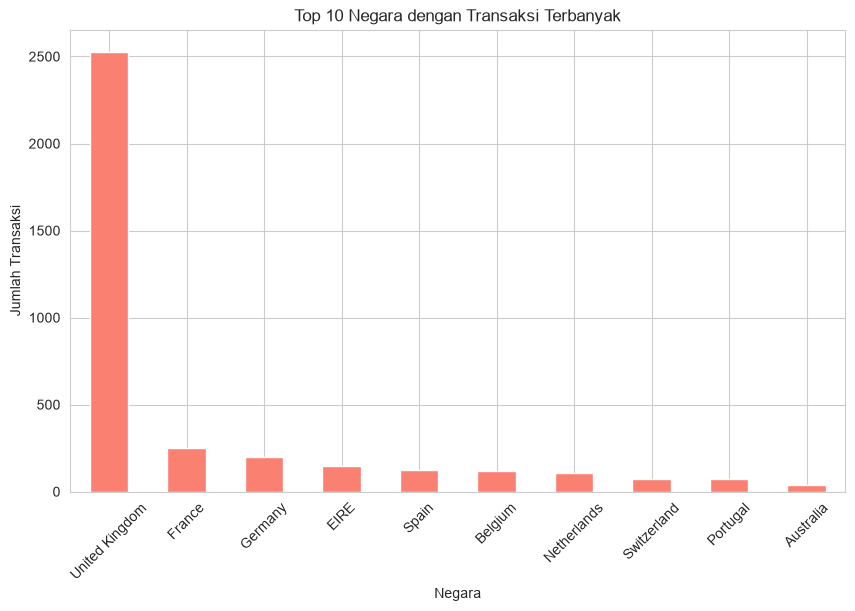

In [14]:
top_countries = df_filtered['Country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar', color='salmon')
plt.title('Top 10 Negara dengan Transaksi Terbanyak')
plt.xlabel('Negara')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.show()

Seluruh rangkaian proses analisis data ini mencakup tahapan pemeriksaan struktur awal dataset melalui informasi tipe data dan identifikasi missing value, yang kemudian dilanjutkan dengan analisis statistik deskriptif untuk mendeteksi nilai ekstrem (outliers) pada variabel seperti UnitPrice dan Quantity. Berdasarkan temuan tersebut, dilakukan proses pembersihan dan penyaringan data (filtering) yang mengubah ukuran dataset, serta divisualisasikan melalui boxplot, histogram distribusi, dan scatter plot untuk melihat pola sebaran data. Selain itu, matriks korelasi atau heatmap menunjukkan bahwa hubungan linear antarvariabel numerik cenderung sangat kecil atau independen, sementara analisis geografi transaksi mengonfirmasi bahwa United Kingdom mendominasi secara signifikan sebagai negara dengan jumlah transaksi terbanyak dibandingkan sembilan negara lainnya dalam daftar sepuluh besar.